## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.metrics import pairwise_distances

# import os pacotes necessários

## Construindo o Dataset

In [ ]:
dataset_path = './images/*.png'
images_filenames = glob.glob(dataset_path)

images_filenames = np.sort(images_filenames)

img_arry = []
for img_path in images_filenames:
  img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2GRAY)
  img_arry.append(img.flatten())

image_dataset = pd.DataFrame(img_arry)

print('shape:', image_dataset.shape)
image_dataset.head()

shape: (45, 16384)


,0,1,2,3,4,5,6,7,8,9,...,16374,16375,16376,16377,16378,16379,16380,16381,16382,16383
0,49,47,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
1,49,47,26,26,26,26,26,26,26,26,...,26,26,26,26,26,26,26,26,26,26
2,49,47,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
3,49,47,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
4,49,47,26,26,26,26,26,26,26,26,...,26,26,26,26,26,26,26,26,26,26


# Testando o PCA

In [ ]:
# Aplique o PCA e selecione apenas 2 componentes, armazene na variável X_new
X_new =

In [ ]:
# plote um gráfico de dispersão para o X_new com os dois componentes

## Avaliando os modelos (n_clusters = 10)

In [ ]:
def plot_images_by_cluster(images_filenames, y, cluster_idx):
  print(f'cluster {cluster_idx}')

  fig, ax = plt.subplots(1, len(images_filenames[y==cluster_idx]))
  i = 0
  for path in images_filenames[y==cluster_idx]:
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2GRAY)
    ax[i].imshow(img, cmap="gray")
    i = i + 1
  plt.show()

### K-Means

(5, 16384)
cluster 0


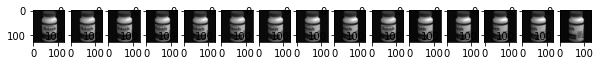

cluster 1


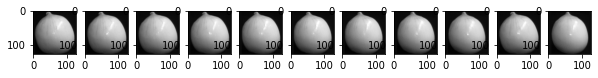

cluster 2


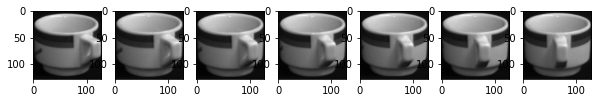

cluster 3


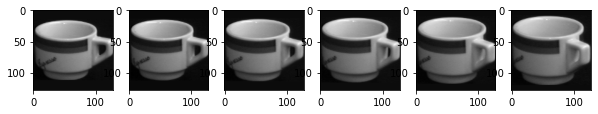

cluster 4


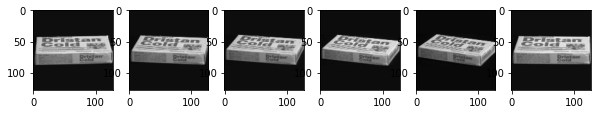

In [ ]:
# treine o k-means o X_new
kmeans = 

y_kmeans = kmeans.labels_

print(kmeans.cluster_centers_.shape)

for k in range(max(y_kmeans) + 1):
  plot_images_by_cluster(images_filenames, y_kmeans, k)

### Aglomerativo

cluster 0


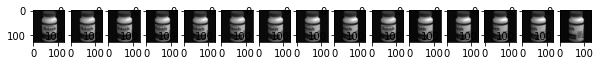

cluster 1


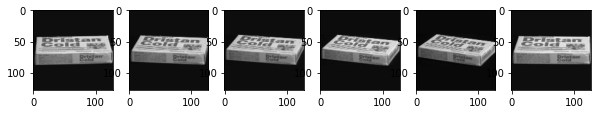

cluster 2


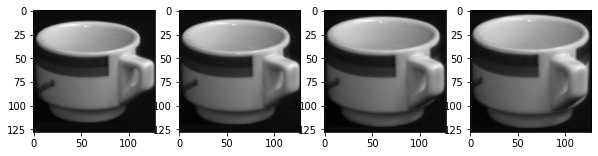

cluster 3


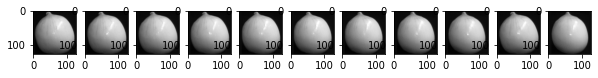

cluster 4


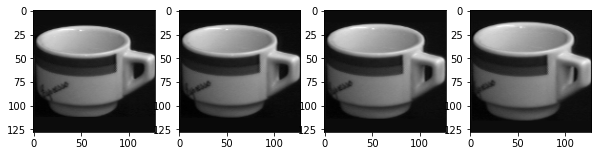

cluster 5


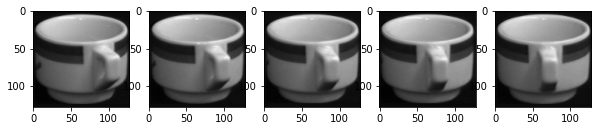

In [ ]:
# treine o cluster aglomerativo com o X_new
agglomerative = 

y_agglomerative = agglomerative.labels_

for k in range(max(y_agglomerative) + 1):
  plot_images_by_cluster(images_filenames, y_agglomerative, k)

### Spectral

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_spectral_embedding.py:261: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  "Graph is not fully connected, spectral embedding may not work as expected."


cluster 0


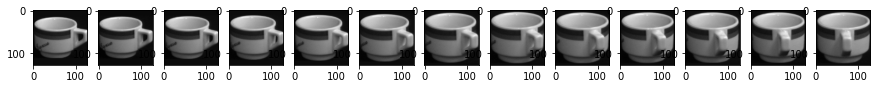

cluster 1


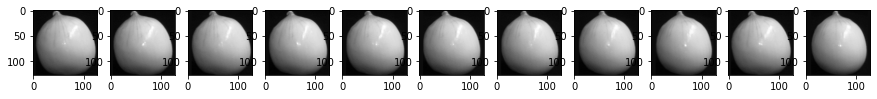

cluster 2


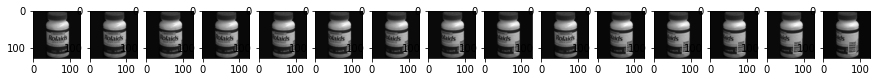

cluster 3


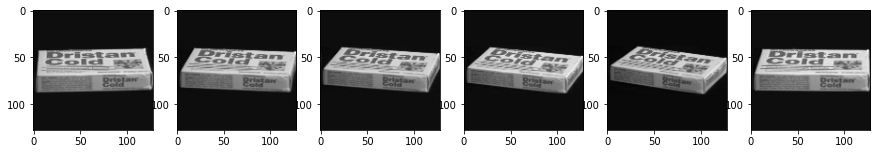

In [ ]:
# treine o Spectral clustering com o X_new

spectral = 

y_spectral = spectral.labels_

for k in range(max(y_spectral) + 1):
  plot_images_by_cluster(images_filenames, y_spectral, k)

## Análise dos Clusters

In [ ]:
# calcule a silhueta para os modelos
sil_kmeans = 
sil_agglomerative = 
sil_spectral = 

print('Silhueta kmeans', sil_kmeans)
print('Silhueta agglomerative', sil_agglomerative)
print('Silhueta spectral', sil_spectral)

print('\n')

y_true = [path.split('/')[2].split('__')[0] for path in images_filenames]

# calcule o NMI para os modelos
nmi_kmeans = 
nmi_agglomerative = 
nmi_spectral =

print('NMI Kmeans: ', nmi_kmeans)
print('NMI Aglomerativo: ', nmi_agglomerative)
print('NMI Spectral: ', nmi_spectral)

Silhueta kmeans 0.3495950936073754
Silhueta agglomerative 0.3495950936073754
Silhueta spectral 0.3495950936073754
Silhueta louvain 0.2891968273492412


NMI Kmeans:  1.0000000000000002
NMI Aglomerativo:  1.0
NMI Spectral:  1.0
NMI Louvain:  0.8616376351602065


In [ ]:
# comente os resultados obtidos

## Testando o LDA e o PCA

In [ ]:
# considere o dataset (train.csv) Titanic disponível em https://www.kaggle.com/competitions/titanic/data?select=train.csv
data = pd.read_csv('./train.csv')
y_true = data['Survived']
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# avalie a remoção de variáveis (tais como Name)
# utilize a função data.info() para avaliar os dados faltantes

In [ ]:
# aplique uma normalização dos dados (StandartScaler ou MinMaxScaler)

In [ ]:
# aplique o LDA e o PCA (2 componentes) considerando o y_true
X_new_PCA = 
X_new_LDA = 

### Treinamento dos modelos

In [ ]:
# escolha um X_new para treinamento dos modelos
y_kmeans = 
y_spectral = 
y_agglomerative = 

### Análise de Clusters

In [ ]:
# calcule a silhueta para os modelos
sil_kmeans = 
sil_agglomerative = 
sil_spectral = 

print('Silhueta kmeans', sil_kmeans)
print('Silhueta agglomerative', sil_agglomerative)
print('Silhueta spectral', sil_spectral)

print('\n')

# calcule o NMI para os modelos
nmi_kmeans = 
nmi_agglomerative = 
nmi_spectral =

print('NMI Kmeans: ', nmi_kmeans)
print('NMI Aglomerativo: ', nmi_agglomerative)
print('NMI Spectral: ', nmi_spectral)

In [ ]:
# comente os resultados obtidos